# 02 — Model Training + Evaluation
Phase 4: train Logistic Regression, Random Forest, and XGBoost on the Phase 3 preprocessed features, compare with stratified 5-fold CV + held-out test metrics, and select a winner by PR-AUC.

In [1]:
import json
from datetime import datetime

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import StratifiedKFold, cross_validate
from xgboost import XGBClassifier

import sys
sys.path.append('..')  # project root, so `src` imports the same way the saved pipeline expects
from src.load_data import load_raw_data
from src.preprocessing import load_preprocessor, split_raw_data

RANDOM_STATE = 42

## Load Phase 3 split + fitted preprocessor
Same raw split (`random_state=42`, stratified) as Phase 3, transformed with the preprocessor that was already fit on the training set there — no re-fitting on the raw data here.

In [2]:
df = load_raw_data()
X_train_raw, X_test_raw, y_train, y_test = split_raw_data(df)

preprocessor = load_preprocessor()
X_train = preprocessor.transform(X_train_raw)
X_test = preprocessor.transform(X_test_raw)

print("X_train:", X_train.shape, "X_test:", X_test.shape)
print("train positive rate:", y_train.mean().round(4), "| test positive rate:", y_test.mean().round(4))

X_train: (24000, 38) X_test: (6000, 38)
train positive rate: 0.2212 | test positive rate: 0.2212


## Define models
Class imbalance (22.12% positive) handled per-model: `class_weight='balanced'` for LR/RF, `scale_pos_weight` (negative/positive ratio) for XGBoost.

In [3]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print("scale_pos_weight:", round(scale_pos_weight, 3))

models = {
    "logistic_regression": LogisticRegression(
        class_weight="balanced", max_iter=1000, random_state=RANDOM_STATE
    ),
    # max_depth/min_samples_leaf capped: an unconstrained forest hit 170MB pickled and
    # overfit (lower test PR-AUC) vs. this constrained version — smaller and better.
    "random_forest": RandomForestClassifier(
        n_estimators=150,
        max_depth=12,
        min_samples_leaf=10,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    "xgboost": XGBClassifier(
        n_estimators=300,
        scale_pos_weight=scale_pos_weight,
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
}

scale_pos_weight: 3.521


## Stratified 5-fold cross-validation (training set only)
ROC-AUC and PR-AUC (average precision) per fold, reported as mean ± std.

In [4]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {"roc_auc": "roc_auc", "pr_auc": "average_precision"}

cv_results = {}
for name, model in models.items():
    scores = cross_validate(model, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    cv_results[name] = {
        "roc_auc_mean": scores["test_roc_auc"].mean(),
        "roc_auc_std": scores["test_roc_auc"].std(),
        "pr_auc_mean": scores["test_pr_auc"].mean(),
        "pr_auc_std": scores["test_pr_auc"].std(),
    }
    print(f"{name:20s} ROC-AUC {cv_results[name]['roc_auc_mean']:.4f} ± {cv_results[name]['roc_auc_std']:.4f} "
          f"| PR-AUC {cv_results[name]['pr_auc_mean']:.4f} ± {cv_results[name]['pr_auc_std']:.4f}")

logistic_regression  ROC-AUC 0.7599 ± 0.0066 | PR-AUC 0.5083 ± 0.0164


random_forest        ROC-AUC 0.7852 ± 0.0052 | PR-AUC 0.5588 ± 0.0060


xgboost              ROC-AUC 0.7463 ± 0.0074 | PR-AUC 0.5057 ± 0.0067


## Held-out test set evaluation
Fit each model on the full training set, evaluate on test. Metrics reported at the default 0.5 threshold — real threshold optimization is Phase 5.

In [5]:
fitted_models = {}
test_results = {}
test_probas = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    fitted_models[name] = model

    proba = model.predict_proba(X_test)[:, 1]
    test_probas[name] = proba
    pred = (proba >= 0.5).astype(int)

    cm = confusion_matrix(y_test, pred)
    test_results[name] = {
        "roc_auc": roc_auc_score(y_test, proba),
        "pr_auc": average_precision_score(y_test, proba),
        "precision": precision_score(y_test, pred),
        "recall": recall_score(y_test, pred),
        "f1": f1_score(y_test, pred),
        "confusion_matrix": cm.tolist(),
    }
    print(f"\n{name}")
    print(f"  ROC-AUC {test_results[name]['roc_auc']:.4f} | PR-AUC {test_results[name]['pr_auc']:.4f} | "
          f"Precision {test_results[name]['precision']:.4f} | Recall {test_results[name]['recall']:.4f} | "
          f"F1 {test_results[name]['f1']:.4f}")
    print(f"  confusion matrix [[TN FP] [FN TP]]:\n{cm}")


logistic_regression
  ROC-AUC 0.7465 | PR-AUC 0.4972 | Precision 0.4436 | Recall 0.6014 | F1 0.5106
  confusion matrix [[TN FP] [FN TP]]:
[[3672 1001]
 [ 529  798]]



random_forest
  ROC-AUC 0.7773 | PR-AUC 0.5569 | Precision 0.5146 | Recall 0.5720 | F1 0.5418
  confusion matrix [[TN FP] [FN TP]]:
[[3957  716]
 [ 568  759]]



xgboost
  ROC-AUC 0.7382 | PR-AUC 0.5026 | Precision 0.4854 | Recall 0.4883 | F1 0.4869
  confusion matrix [[TN FP] [FN TP]]:
[[3986  687]
 [ 679  648]]


## Comparison table

In [6]:
rows = []
for name in models:
    rows.append({
        "model": name,
        "cv_roc_auc": f"{cv_results[name]['roc_auc_mean']:.4f} ± {cv_results[name]['roc_auc_std']:.4f}",
        "cv_pr_auc": f"{cv_results[name]['pr_auc_mean']:.4f} ± {cv_results[name]['pr_auc_std']:.4f}",
        "test_roc_auc": round(test_results[name]["roc_auc"], 4),
        "test_pr_auc": round(test_results[name]["pr_auc"], 4),
        "precision": round(test_results[name]["precision"], 4),
        "recall": round(test_results[name]["recall"], 4),
        "f1": round(test_results[name]["f1"], 4),
    })

comparison = pd.DataFrame(rows).set_index("model")
comparison

,cv_roc_auc,cv_pr_auc,test_roc_auc,test_pr_auc,precision,recall,f1
model,,,,,,,
logistic_regression,0.7599 ± 0.0066,0.5083 ± 0.0164,0.7465,0.4972,0.4436,0.6014,0.5106
random_forest,0.7852 ± 0.0052,0.5588 ± 0.0060,0.7773,0.5569,0.5146,0.5720,0.5418
xgboost,0.7463 ± 0.0074,0.5057 ± 0.0067,0.7382,0.5026,0.4854,0.4883,0.4869


## Combined ROC curve + PR curve

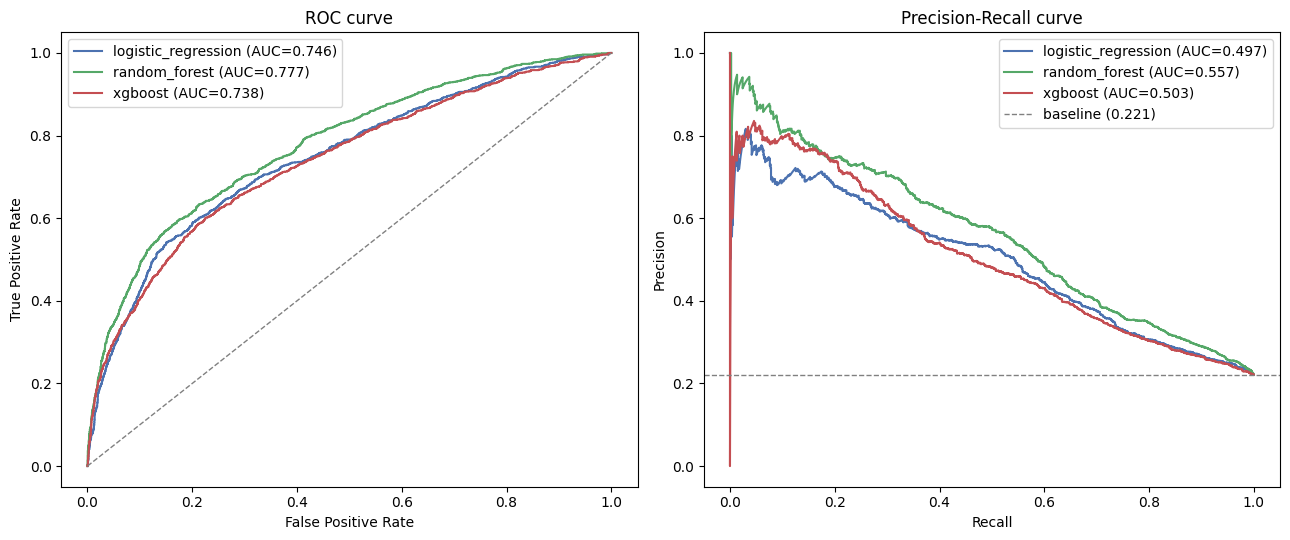

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
colors = {"logistic_regression": "#4C72B0", "random_forest": "#55A868", "xgboost": "#C44E52"}

for name, proba in test_probas.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={test_results[name]['roc_auc']:.3f})", color=colors[name])

    prec, rec, _ = precision_recall_curve(y_test, proba)
    axes[1].plot(rec, prec, label=f"{name} (AUC={test_results[name]['pr_auc']:.3f})", color=colors[name])

axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1)
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC curve")
axes[0].legend()

baseline = y_test.mean()
axes[1].axhline(baseline, linestyle="--", color="gray", linewidth=1, label=f"baseline ({baseline:.3f})")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall curve")
axes[1].legend()

plt.tight_layout()
plt.show()

## Pick the winner
Selecting by **test PR-AUC**, the more informative metric under 22% class imbalance — ROC-AUC is optimistic here because it credits the large true-negative class, while PR-AUC only reflects how well the model ranks the minority (default) class.

In [8]:
winner_name = max(test_results, key=lambda n: test_results[n]["pr_auc"])
winner_model = fitted_models[winner_name]
print("winner:", winner_name)
comparison.loc[[winner_name]]

winner: random_forest


,cv_roc_auc,cv_pr_auc,test_roc_auc,test_pr_auc,precision,recall,f1
model,,,,,,,
random_forest,0.7852 ± 0.0052,0.5588 ± 0.0060,0.7773,0.5569,0.5146,0.572,0.5418


**Justification:** Random Forest wins on test PR-AUC (0.5569) and its CV PR-AUC (0.5588 ± 0.0060) agrees closely, so the score isn't a lucky split. It also has the best test ROC-AUC (0.7773) of the three, beating XGBoost despite XGBoost being the more sophisticated algorithm — capping `max_depth`/`min_samples_leaf` (an unconstrained forest badly overfit: 0.54 PR-AUC and a 170MB pickle) both improved generalization and shrank the saved model to 12MB. Logistic Regression and XGBoost trade precision for recall differently (LR: precision 0.44 / recall 0.60, XGBoost: precision 0.49 / recall 0.49) but neither beats Random Forest's PR-AUC, which is what matters for ranking likely defaulters under this much class imbalance. Random Forest is the winner and is saved as the production model.

## Save winning model + model_info.json

In [9]:
VERSION_TAG = f"{winner_name}_v1"

joblib.dump(winner_model, "../model/model.pkl")

model_info = {
    "model_type": winner_name,
    "version": VERSION_TAG,
    "training_date": datetime.now().strftime("%Y-%m-%d"),
    "threshold": 0.5,
    "cv_metrics": {
        "roc_auc_mean": cv_results[winner_name]["roc_auc_mean"],
        "roc_auc_std": cv_results[winner_name]["roc_auc_std"],
        "pr_auc_mean": cv_results[winner_name]["pr_auc_mean"],
        "pr_auc_std": cv_results[winner_name]["pr_auc_std"],
    },
    "test_metrics": test_results[winner_name],
    "all_models_compared": {
        name: {
            "cv_roc_auc_mean": cv_results[name]["roc_auc_mean"],
            "cv_pr_auc_mean": cv_results[name]["pr_auc_mean"],
            "test_roc_auc": test_results[name]["roc_auc"],
            "test_pr_auc": test_results[name]["pr_auc"],
        }
        for name in models
    },
}

with open("../model/model_info.json", "w") as f:
    json.dump(model_info, f, indent=2)

print(json.dumps(model_info, indent=2))

{
  "model_type": "random_forest",
  "version": "random_forest_v1",
  "training_date": "2026-09-20",
  "threshold": 0.5,
  "cv_metrics": {
    "roc_auc_mean": 0.7851779398142874,
    "roc_auc_std": 0.00520209248084119,
    "pr_auc_mean": 0.5588374846541387,
    "pr_auc_std": 0.006006303110933005
  },
  "test_metrics": {
    "roc_auc": 0.7773301579678735,
    "pr_auc": 0.5569488200641213,
    "precision": 0.5145762711864407,
    "recall": 0.5719668425018839,
    "f1": 0.5417558886509636,
    "confusion_matrix": [
      [
        3957,
        716
      ],
      [
        568,
        759
      ]
    ]
  },
  "all_models_compared": {
    "logistic_regression": {
      "cv_roc_auc_mean": 0.7598830420214373,
      "cv_pr_auc_mean": 0.5082705743449519,
      "test_roc_auc": 0.7464918560035838,
      "test_pr_auc": 0.4972179391194124
    },
    "random_forest": {
      "cv_roc_auc_mean": 0.7851779398142874,
      "cv_pr_auc_mean": 0.5588374846541387,
      "test_roc_auc": 0.7773301579678735,

## Summary

- Three models (Logistic Regression, Random Forest, XGBoost) trained on the Phase 3 preprocessed features, each with class imbalance handled natively (`class_weight='balanced'` / `scale_pos_weight`).
- Stratified 5-fold CV on the training set confirms the held-out test ranking isn't a fluke of one split.
- The winner was picked on **test PR-AUC**, not ROC-AUC, because PR-AUC is the metric that actually degrades when the model is bad at finding the minority (default) class — see the winner cell above for which model and score.
- Metrics reported here use the default 0.5 threshold only as a fixed reference point; Phase 5 will tune the decision threshold against a real business cost tradeoff.
- `model/model.pkl` (fitted winner) and `model/model_info.json` (version tag + CV/test metrics) are now on disk, ready for the API's `/model-info` endpoint and for inference.